# MOGA-Phonons correlation heatmaps for dataframe000013 and dataframe000014

This notebook aggregates `dataframe000013.pkl` and `dataframe000014.pkl`, keeps only the **top 5 overall** solutions for each `(dataset, mass, lattice parameter)` combination, and generates publication-quality Pearson and Spearman correlation heatmaps.

The selection is **not** top 5 per generation. It is top 5 overall by `fitness_norm` for each independent dataframe and each `(m, a)` pair.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional but useful for high-resolution notebook display.
%config InlineBackend.figure_format = "retina"

# -----------------------------------------------------------------------------
# User settings
# -----------------------------------------------------------------------------

# Update this path if your pickle files are somewhere else.
DATA_DIR = Path("./dataframes/")   # e.g., Path("/Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes")

DATAFRAME_FILES = {
    "dataframe000013": DATA_DIR / "dataframe000013.pkl",
    "dataframe000014": DATA_DIR / "dataframe000014.pkl",
    "dataframe000015": DATA_DIR / "dataframe000015.pkl",
    "dataframe000016": DATA_DIR / "dataframe000016.pkl",
}

OUTPUT_DIR = Path("correlation_heatmaps_top5_overall")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 5
RANK_BY = "fitness_norm"

# Figure settings.
FIGSIZE = (9.0, 7.5)
DPI = 300
SAVE_FORMATS = ("pdf", "png")

# Choose which scalar columns to include in the correlation analysis.
# The notebook will keep only columns that actually exist in the dataframe.
REQUESTED_COLUMNS = [
    "mass",
    "m",
    "a_val",
    "alat",
    "a_latt",
    "lattice_parameter",
    "alpha0",
    "alpha_0",
    "alpha1",
    "alpha_1",
    "beta1",
    "beta_1",
    "alpha2",
    "alpha_2",
    "beta2",
    "beta_2",
    "fitness1",
    "f1",
    "fitness2",
    "f2",
    "fitness3",
    "f3",
    "fitness_norm",
    "fnorm",
    "min_frequency",
    "min_freq",
    "max_frequency",
    "max_freq",
    "num_imaginary",
    "n_imaginary",
]


In [15]:
def find_first_existing(candidates, columns):
    """Return the first column name from candidates that exists in columns."""
    for col in candidates:
        if col in columns:
            return col
    return None


def load_dataframe(path, dataset_label):
    """Load a pickle dataframe and add a dataset label."""
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Update DATA_DIR or DATAFRAME_FILES at the top of the notebook."
        )
    df = pd.read_pickle(path)
    df = df.copy()
    df["dataset"] = dataset_label
    return df


def rename_for_display(columns):
    """Make compact, LaTeX-like labels for heatmap axes."""
    label_map = {
        "mass": "$m$",
        "m": "$m$",
        "a_val": "$a_0$",
        "alat": "$a_0$",
        "a_latt": "$a_0$",
        "lattice_parameter": "$a_0$",
        "alpha0": r"$\alpha_0$",
        "alpha_0": r"$\alpha_0$",
        "alpha1": r"$\alpha_1$",
        "alpha_1": r"$\alpha_1$",
        "beta1": r"$\beta_1$",
        "beta_1": r"$\beta_1$",
        "alpha2": r"$\alpha_2$",
        "alpha_2": r"$\alpha_2$",
        "beta2": r"$\beta_2$",
        "beta_2": r"$\beta_2$",
        "fitness1": r"$f_1$",
        "f1": r"$f_1$",
        "fitness2": r"$f_2$",
        "f2": r"$f_2$",
        "fitness3": r"$f_3$",
        "f3": r"$f_3$",
        "fitness_norm": r"$f_{\mathrm{norm}}$",
        "fnorm": r"$f_{\mathrm{norm}}$",
        "min_frequency": r"$\omega_{\min}$",
        "min_freq": r"$\omega_{\min}$",
        "max_frequency": r"$\omega_{\max}$",
        "max_freq": r"$\omega_{\max}$",
        "num_imaginary": r"$N_-$",
        "n_imaginary": r"$N_-$",
    }
    return [label_map.get(c, c) for c in columns]


def save_current_figure(stem, output_dir=OUTPUT_DIR, formats=SAVE_FORMATS):
    """Save current matplotlib figure in multiple formats."""
    saved = []
    for ext in formats:
        outpath = output_dir / f"{stem}.{ext}"
        plt.savefig(outpath, dpi=DPI, bbox_inches="tight")
        saved.append(outpath)
    print("Saved:")
    for path in saved:
        print(f"  {path}")
    return saved


In [16]:
# -----------------------------------------------------------------------------
# Load and aggregate the two independent dataframes
# -----------------------------------------------------------------------------

frames = []
for label, path in DATAFRAME_FILES.items():
    tmp = load_dataframe(path, label)
    print(f"{label}: {tmp.shape[0]:,} rows, {tmp.shape[1]:,} columns")
    frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
print(f"\nAggregated dataframe before filtering: {df_all.shape[0]:,} rows, {df_all.shape[1]:,} columns")
df_all.head()


dataframe000013: 105,000 rows, 35 columns
dataframe000014: 105,000 rows, 35 columns
dataframe000015: 105,000 rows, 35 columns
dataframe000016: 105,000 rows, 35 columns

Aggregated dataframe before filtering: 420,000 rows, 35 columns


,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path,dataset
0,simulation000588,1,5,0,population,2026-05-22T19:33:42.238245,50.0,2.0,5,5.607430,...,"[0.8275024, 0.8275024, 0.8275024]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.8275024, 0.8275024, 0.8275024], [0.8291954...","[0.8275024, 0.8275024, 0.8275024, 0.8291954, 0...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
1,simulation000588,1,92,1,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.189523,...,"[1.562392, 1.562392, 1.562392]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.562392, 1.562392, 1.562392], [1.563087, 1....","[1.562392, 1.562392, 1.562392, 1.563087, 1.563...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
2,simulation000588,1,44,2,population,2026-05-22T19:33:42.238245,50.0,2.0,5,3.931578,...,"[-1.0034583, -1.0034583, -1.0034583]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.0034583, -1.0034583, -1.0034583], [-1.002...","[-1.0034583, -1.0034583, -1.0034583, -1.002285...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
3,simulation000588,1,155,3,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.349680,...,"[1.0862614, 1.0862614, 1.0862614]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.0862614, 1.0862614, 1.0862614], [1.0880687...","[1.0862614, 1.0862614, 1.0862614, 1.0880687, 1...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
4,simulation000588,1,125,4,population,2026-05-22T19:33:42.238245,50.0,2.0,5,8.587408,...,"[-1.2866693, -1.2866693, -1.2866693]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.2866693, -1.2866693, -1.2866693], [-1.284...","[-1.2866693, -1.2866693, -1.2866693, -1.284834...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013


In [17]:
# -----------------------------------------------------------------------------
# Detect key column names
# -----------------------------------------------------------------------------

mass_col = find_first_existing(["mass", "m"], df_all.columns)
alat_col = find_first_existing(["a_val", "alat", "a_latt", "lattice_parameter"], df_all.columns)
rank_col = find_first_existing([RANK_BY, "fitness_norm", "fnorm"], df_all.columns)

if mass_col is None:
    raise ValueError("Could not find a mass column. Expected one of: mass, m")

if alat_col is None:
    raise ValueError("Could not find a lattice-parameter column. Expected one of: a_val, alat, a_latt, lattice_parameter")

if rank_col is None:
    raise ValueError("Could not find a ranking column. Expected fitness_norm or fnorm.")

print(f"Detected mass column: {mass_col}")
print(f"Detected lattice-parameter column: {alat_col}")
print(f"Detected ranking column: {rank_col}")


Detected mass column: mass
Detected lattice-parameter column: a_val
Detected ranking column: fitness_norm


In [18]:
# -----------------------------------------------------------------------------
# Keep only the top 5 overall per dataset, mass, and lattice parameter
# -----------------------------------------------------------------------------
#
# This is the key filtering step.
#
# It selects the top TOP_K rows after sorting by fitness_norm for each group:
#     dataset, mass, lattice parameter
#
# It does NOT group by generation, so the selected rows are the top 5 overall
# for each independent dataframe and each (m, a) pair.
# -----------------------------------------------------------------------------

df = (
    df_all.sort_values(rank_col, ascending=False)
    .groupby(["dataset", mass_col, alat_col], group_keys=False)
    .head(TOP_K)
    .copy()
)

print(f"Filtered dataframe after top-{TOP_K}-overall selection: {df.shape[0]:,} rows")

summary = (
    df.groupby(["dataset", mass_col, alat_col])
    .size()
    .reset_index(name="n_selected")
)

print("\nSelection count summary:")
print(summary["n_selected"].describe())
summary.head(15)


Filtered dataframe after top-5-overall selection: 840 rows

Selection count summary:
count    168.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: n_selected, dtype: float64


,dataset,mass,a_val,n_selected
0,dataframe000013,50.0,2.0,5
1,dataframe000013,50.0,2.2,5
2,dataframe000013,50.0,2.4,5
3,dataframe000013,50.0,2.6,5
4,dataframe000013,50.0,2.8,5
5,dataframe000013,50.0,3.0,5
6,dataframe000013,50.0,3.2,5
7,dataframe000013,60.0,2.0,5
8,dataframe000013,60.0,2.2,5
9,dataframe000013,60.0,2.4,5


In [19]:
# Optional sanity check: show the selected rows for one mass/lattice-parameter pair.

example_mass = sorted(df[mass_col].dropna().unique())[0]
example_alat = sorted(df[alat_col].dropna().unique())[0]

check = df[
    np.isclose(df[mass_col].astype(float), float(example_mass))
    & np.isclose(df[alat_col].astype(float), float(example_alat))
].sort_values(["dataset", rank_col], ascending=[True, False])

display_cols = [
    c for c in ["dataset", mass_col, alat_col, "generation", "solution_idx", "rank", rank_col]
    if c in check.columns
]

check[display_cols].head(20)


,dataset,mass,a_val,generation,rank,fitness_norm
1774,dataframe000013,50.0,2.0,355,4,1.708806
1782,dataframe000013,50.0,2.0,357,2,1.708806
1769,dataframe000013,50.0,2.0,354,4,1.708806
2068,dataframe000013,50.0,2.0,414,3,1.708806
1770,dataframe000013,50.0,2.0,355,0,1.708806
107047,dataframe000014,50.0,2.0,410,2,1.712586
107043,dataframe000014,50.0,2.0,409,3,1.712586
107244,dataframe000014,50.0,2.0,449,4,1.712586
107251,dataframe000014,50.0,2.0,451,1,1.712586
107250,dataframe000014,50.0,2.0,451,0,1.712586


In [20]:
# -----------------------------------------------------------------------------
# Build the scalar dataframe used for correlations
# -----------------------------------------------------------------------------

preferred_groups = [
    ["mass", "m"],
    ["a_val", "alat", "a_latt", "lattice_parameter"],
    ["alpha0", "alpha_0"],
    ["alpha1", "alpha_1"],
    ["beta1", "beta_1"],
    ["alpha2", "alpha_2"],
    ["beta2", "beta_2"],
  #  ["fitness1", "f1"],
  #  ["fitness2", "f2"],
  #  ["fitness3", "f3"],
  #  ["fitness_norm", "fnorm"],
  #  ["min_frequency", "min_freq"],
    ["max_frequency", "max_freq"],
  #  ["num_imaginary", "n_imaginary"],
]

correlation_columns = []
for group in preferred_groups:
    col = find_first_existing(group, df.columns)
    if col is not None:
        correlation_columns.append(col)

# Remove accidental duplicates while preserving order.
correlation_columns = list(dict.fromkeys(correlation_columns))

corr_df = df[correlation_columns].copy()

# Convert to numeric and drop rows with missing values in selected columns.
for col in corr_df.columns:
    corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")

before = corr_df.shape[0]
corr_df = corr_df.dropna(axis=0, how="any")
after = corr_df.shape[0]

print(f"Correlation columns ({len(correlation_columns)}):")
print(correlation_columns)
print(f"\nRows available for correlation: {after:,} / {before:,}")
corr_df.head()


Correlation columns (8):
['mass', 'a_val', 'alpha0', 'alpha1', 'beta1', 'alpha2', 'beta2', 'max_frequency']

Rows available for correlation: 840 / 840


,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,max_frequency
214621,50.0,2.2,5.173158,-0.321338,-0.017194,0.000162,-0.650614,6.166276
214938,50.0,2.2,5.173158,-0.321338,0.025992,0.000162,-0.650614,6.168211
214926,50.0,2.2,5.173158,-0.321338,0.025992,0.000162,-0.650614,6.168211
214927,50.0,2.2,5.173158,-0.321338,0.631618,0.000162,-0.650614,7.196012
214928,50.0,2.2,5.173158,-0.321338,0.025992,0.000162,-0.650614,6.168211


In [21]:
# -----------------------------------------------------------------------------
# Compute Pearson and Spearman correlation matrices
# -----------------------------------------------------------------------------

pearson_corr = corr_df.corr(method="pearson")
spearman_corr = corr_df.corr(method="spearman")

display_labels = rename_for_display(correlation_columns)

pearson_corr_display = pearson_corr.copy()
spearman_corr_display = spearman_corr.copy()

pearson_corr_display.index = display_labels
pearson_corr_display.columns = display_labels
spearman_corr_display.index = display_labels
spearman_corr_display.columns = display_labels

pearson_corr_display


,$m$,$a_0$,$\alpha_0$,$\alpha_1$,$\beta_1$,$\alpha_2$,$\beta_2$,$\omega_{\max}$
$m$,1.000000e+00,7.976020e-16,0.025485,0.008805,0.004955,0.050798,-0.047425,-0.675069
$a_0$,7.976020e-16,1.000000e+00,-0.103370,-0.046083,-0.017036,-0.053629,0.134370,-0.098589
$\alpha_0$,2.548516e-02,-1.033699e-01,1.000000,-0.503921,-0.033669,0.146667,-0.284079,0.578479
$\alpha_1$,8.805093e-03,-4.608347e-02,-0.503921,1.000000,0.006932,0.089906,-0.597482,-0.183522
$\beta_1$,4.955107e-03,-1.703629e-02,-0.033669,0.006932,1.000000,-0.046103,0.036843,-0.015412
$\alpha_2$,5.079783e-02,-5.362896e-02,0.146667,0.089906,-0.046103,1.000000,-0.620787,-0.085196
$\beta_2$,-4.742459e-02,1.343702e-01,-0.284079,-0.597482,0.036843,-0.620787,1.000000,-0.185892
$\omega_{\max}$,-6.750686e-01,-9.858876e-02,0.578479,-0.183522,-0.015412,-0.085196,-0.185892,1.000000


In [46]:
def plot_correlation_heatmap(corr, title, stem):
    """
    Plot and save a publication-quality correlation heatmap using matplotlib only.
    """
    fig, ax = plt.subplots(figsize=FIGSIZE)

    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm", origin="upper")

    # Ticks and labels
    ax.set_xticks(np.arange(corr.shape[1]))
    ax.set_yticks(np.arange(corr.shape[0]))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", rotation_mode="anchor", fontsize=16)
    ax.set_yticklabels(corr.index, fontsize=16)

    # Cell annotations
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = corr.values[i, j]
            text_color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=12, color=text_color)

    # Grid lines
    ax.set_xticks(np.arange(-0.5, corr.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, corr.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Mirrored publication-style axes
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=False,
        right=False,
        length=5,
        width=1.1,
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)

    ax.set_title(title, fontsize=18, pad=14)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation coefficient", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    fig.tight_layout()
    saved = save_current_figure(stem)

    plt.show()
    return fig, ax, saved


Saved:
  correlation_heatmaps_top5_overall/pearson_correlation_heatmap_top5_overall.pdf
  correlation_heatmaps_top5_overall/pearson_correlation_heatmap_top5_overall.png


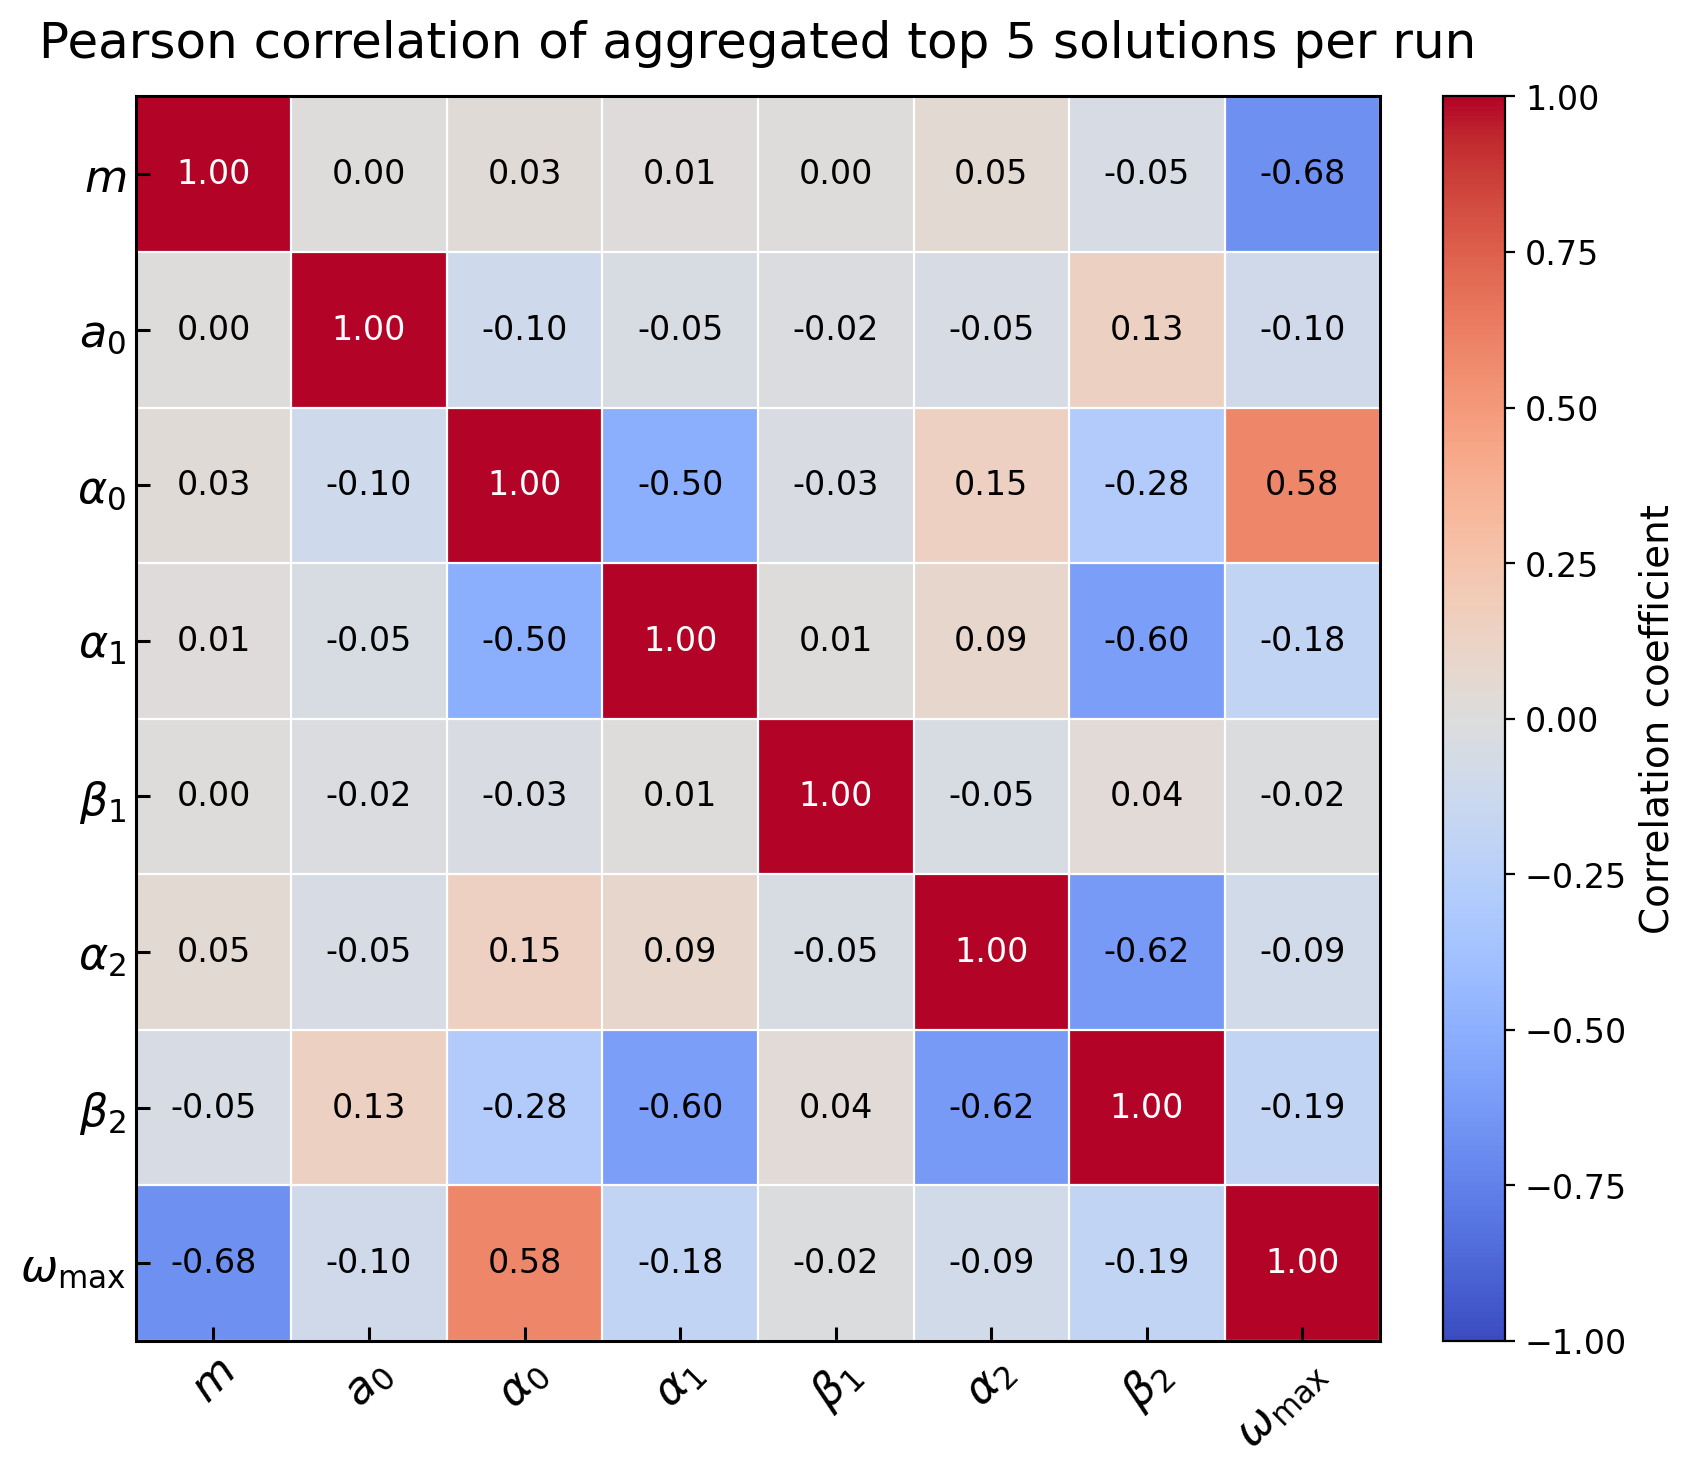

In [47]:
fig, ax, saved_pearson = plot_correlation_heatmap(
    pearson_corr_display,
    title=f"Pearson correlation of aggregated top 5 solutions per run",
    stem="pearson_correlation_heatmap_top5_overall",
)


Saved:
  correlation_heatmaps_top5_overall/spearman_correlation_heatmap_top5_overall.pdf
  correlation_heatmaps_top5_overall/spearman_correlation_heatmap_top5_overall.png


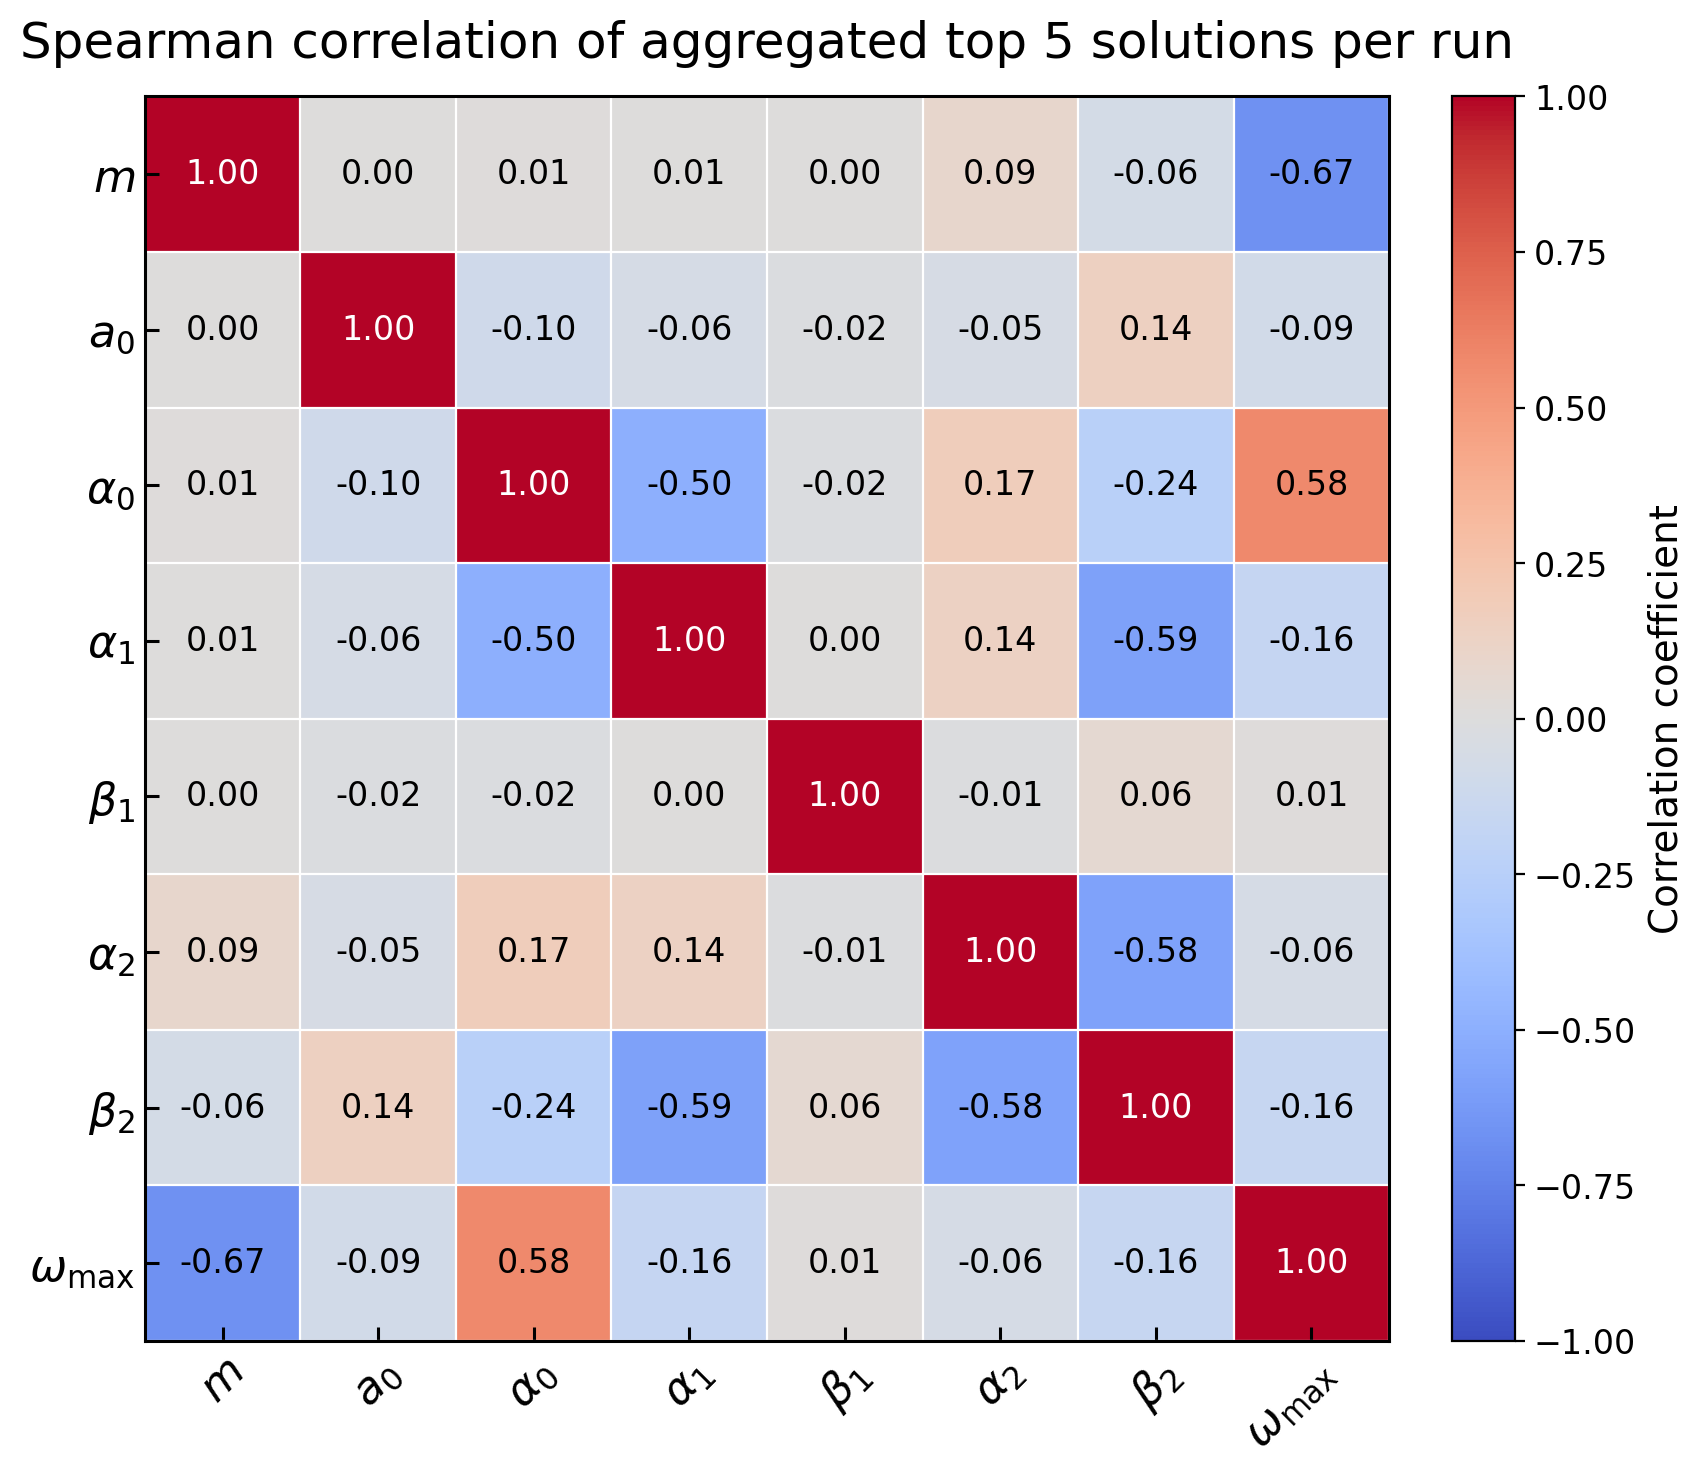

In [49]:
fig, ax, saved_spearman = plot_correlation_heatmap(
    spearman_corr_display,
    title=f"Spearman correlation of aggregated top 5 solutions per run",
    stem="spearman_correlation_heatmap_top5_overall",
)


In [50]:
# -----------------------------------------------------------------------------
# Save numerical correlation matrices as CSV files
# -----------------------------------------------------------------------------

pearson_csv = OUTPUT_DIR / "pearson_correlation_matrix_top5_overall.csv"
spearman_csv = OUTPUT_DIR / "spearman_correlation_matrix_top5_overall.csv"

pearson_corr.to_csv(pearson_csv)
spearman_corr.to_csv(spearman_csv)

print("Saved numerical matrices:")
print(f"  {pearson_csv}")
print(f"  {spearman_csv}")


Saved numerical matrices:
  correlation_heatmaps_top5_overall/pearson_correlation_matrix_top5_overall.csv
  correlation_heatmaps_top5_overall/spearman_correlation_matrix_top5_overall.csv


## Notes for manuscript use

This notebook performs the correlation analysis on the top five overall solutions, ranked by \(f_{\mathrm{norm}}\), for each independent dataset and each \((m,a)\) pair. This selection emphasizes the best solutions produced by each optimization sweep rather than sampling the best individuals from every generation.

The output files are saved in:

```text
correlation_heatmaps_top5_overall/
```

The main figure files are:

```text
pearson_correlation_heatmap_top5_overall.pdf
spearman_correlation_heatmap_top5_overall.pdf
```
